In [1]:
import cv2
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# 🎯 Purporse project

* ### 1. Add Dataframe (df) features to ensure the LLM prompting is relevant to dataframe

* ### 2. Integration PDF report to dataframe for as reliable chatbot

* ### 3. Match recommendation system toward the images for where the product will be shown in UI as ranking recommendation

* ### 4. Merge LSTM model for sales and profit_status prediction (Optional)

## Load images dataset

In [2]:
from PIL import Image

IMAGE_DIR = "../../../fashion_images/dataset_clean"

images = []
image_paths = []

# iterate to call images data
for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        if filename.lower().endswith(".jpg"):
            path = os.path.join(root, filename)
            image = Image.open(path).convert("RGB")
            images.append(image)
            image_paths.append(path)
    
print(f"Loaded {len(images)} JPG Images")

Loaded 8625 JPG Images


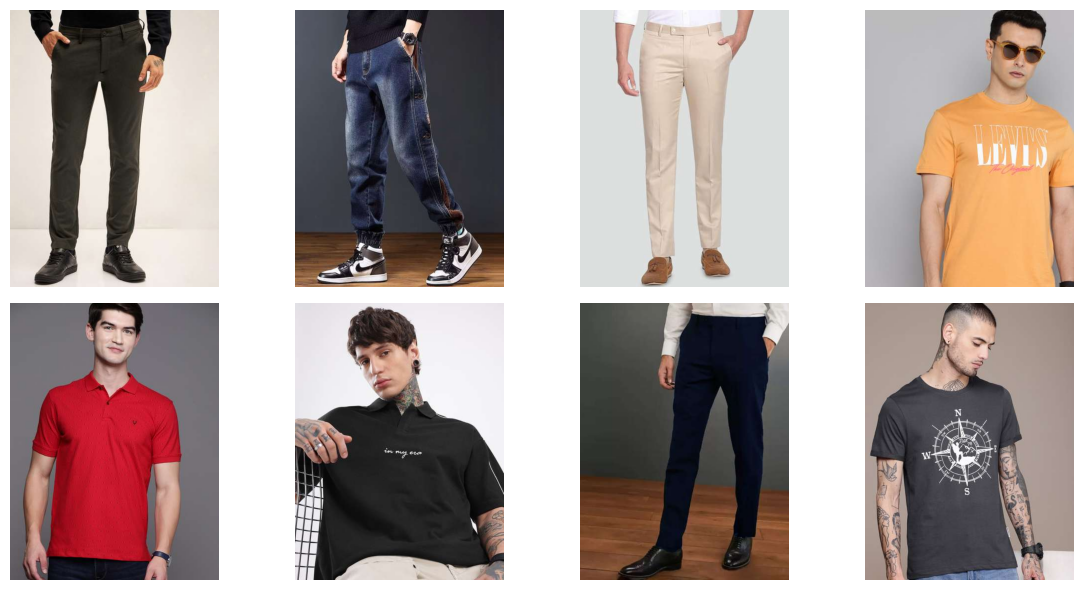

In [23]:
# Show random images

import random
import matplotlib.pyplot as plt

def show_random_images(images, n=8, cols=4, figsize=(12, 6)):
    n = min(n, len(images))
    selected = random.sample(images, n)

    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Usage
show_random_images(images, n=8)

In [25]:
# Load parquet images dataset
df_images = pd.read_parquet("../../../MLOps/database/data/raw/matched_fashion_dataset_300k_rows.parquet")
df_images

,item_id,category,subcategory,sleeve_type,season,fabric,occasion,formality_level,size_range,brand,view_count,click_count,purchase_count,length_cm,price,stocks
0,TNC_000001,tops,formal_shirts,long,all-season,cotton,party,high,XXL,Tommy Hilfiger,91,2,56,69,365256,119
1,TNC_000002,tops,casual_shirts,long,summer,linen,casual,high,L,Adidas,212,125,83,70,249729,104
2,TNC_000003,bottoms,jeans,long,winter,fleece,casual,high,XS,ZARA,166,148,176,95,276724,97
3,TNC_000004,bottoms,jeans,long,summer,denim,casual,low,XXL,Nike,132,410,63,103,314195,123
4,TNC_000005,tops,casual_shirts,long,winter,denim,office,low,L,Nike,506,89,3,77,213034,162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,TNC_299996,tops,casual_shirts,long,winter,linen,party,high,L,ZARA,2704,154,37,73,331202,169
299996,TNC_299997,bottoms,men_cargos,long,summer,fleece,party,low,XXL,Adidas,190,255,70,109,330060,107
299997,TNC_299998,bottoms,jeans,long,summer,polyester,casual,medium,XXL,Nike,741,7,23,103,351697,101
299998,TNC_299999,tops,printed_hoodies,long,summer,polyester,casual,high,XS,Adidas,453,136,6,79,396990,45


## Load repot anaylsis PDF

In [18]:
# ============================================================
# CELL 1 — Install dependencies (run once)
# ============================================================
# !pip install langchain langchain-community pypdf -q


# ============================================================
# CELL 2 — Load PDF with LangChain
# ============================================================
from langchain_community.document_loaders import PyPDFLoader

PDF_DIR = "../../../pipelines/ai_engineer/docs/RAG_Analysis_Report.pdf"
loader = PyPDFLoader(PDF_DIR)
pages = loader.load_and_split()

print(f"✅ Loaded {len(pages)} pages from PDF")


# ============================================================
# CELL 3 — Display as Styled RAG Report UI in Notebook
# ============================================================
from IPython.display import display, HTML
import re
from datetime import datetime

# ── helpers ──────────────────────────────────────────────────

def extract_meta(pages):
    """Pull title, date, subject, preparer from first page text."""
    text = pages[0].page_content if pages else ""
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    # Date
    date_match = re.search(
        r"(January|February|March|April|May|June|July|August|"
        r"September|October|November|December)\s+\d{1,2},?\s+\d{4}", text, re.I
    )
    date = date_match.group(0) if date_match else datetime.today().strftime("%B %d, %Y")

    # Title — longest short line on page 1
    title_candidates = [l for l in lines if 8 < len(l) < 80]
    title = title_candidates[0] if title_candidates else "RAG Analysis Report"

    # Subject — second candidate
    subject = title_candidates[1] if len(title_candidates) > 1 else "Business Intelligence"

    # Prepared by
    prep = re.search(r"Prepared\s+by[:\s]+([^\n]+)", text, re.I)
    prepared_by = prep.group(1).strip() if prep else "Intelligence Team"

    # Classification
    cls = re.search(r"Classification[:\s]+([^\n]+)", text, re.I)
    classification = cls.group(1).strip() if cls else "Confidential — Internal Use Only"

    return dict(title=title, subject=subject, date=date,
                prepared_by=prepared_by, classification=classification)


def build_toc(pages):
    """Extract Q1/Q2 style headings or first line per page for TOC."""
    toc = []
    seen = set()
    for i, page in enumerate(pages):
        for line in page.page_content.split("\n"):
            line = line.strip()
            if re.match(r"^Q\d+[\.\)]", line, re.I) or re.match(r"^\d+[\.\)]\s+[A-Z]", line):
                short = line[:70] + ("..." if len(line) > 70 else "")
                if short not in seen:
                    seen.add(short)
                    toc.append((short, i + 1))
    if not toc:
        for i, page in enumerate(pages[:8]):
            first = next((l.strip() for l in page.page_content.split("\n") if l.strip()), "")
            short = first[:70] + ("..." if len(first) > 70 else "")
            toc.append((short, i + 1))
    return toc[:10]


def render_report(pages):
    """Render full styled RAG Report HTML inside a Jupyter cell."""
    meta   = extract_meta(pages)
    toc    = build_toc(pages)

    # ── TOC rows ──────────────────────────────────────────────
    toc_rows = "".join(
        f'<div class="toc-item">{item}'
        f'<span class="toc-pg">p.{pg}</span></div>'
        for item, pg in toc
    )
    toc_rows += '<div class="toc-item">Appendix A. Results Summary Table</div>'

    # ── Page sections ─────────────────────────────────────────
    page_sections = ""
    for i, page in enumerate(pages):
        safe = (page.page_content
                .replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;"))
        page_sections += f"""
        <div class="page-card">
            <div class="page-label">Page {i+1} of {len(pages)}</div>
            <div class="page-text">{safe}</div>
        </div>"""

    # ── Full HTML ─────────────────────────────────────────────
    html = f"""
    <div id="rag-report">
    <style>
        #rag-report {{
            font-family: Arial, sans-serif;
            background: #f0f4f8;
            padding: 0 0 40px 0;
            color: #1a1a2e;
        }}
        #rag-report .top-bar {{
            background: #0d1b3e;
            color: #fff;
            padding: 11px 32px;
            display: flex;
            justify-content: space-between;
            font-size: 13px;
            font-weight: bold;
            letter-spacing: .5px;
            border-bottom: 3px solid #2563eb;
        }}
        #rag-report .wrapper {{
            max-width: 900px;
            margin: 0 auto;
            padding: 36px 20px;
        }}
        #rag-report .hero {{
            background: #0d1b3e;
            border-radius: 8px;
            padding: 50px 48px;
            margin-bottom: 22px;
            text-align: center;
        }}
        #rag-report .hero h1 {{
            color: #fff;
            font-size: 50px;
            font-weight: 900;
            margin: 0;
            letter-spacing: -1px;
        }}
        #rag-report .meta-box {{
            background: linear-gradient(135deg,#2563eb,#3b82f6);
            border-radius: 8px;
            padding: 30px 48px;
            margin-bottom: 30px;
            text-align: center;
            color: #fff;
        }}
        #rag-report .meta-box .meta-title {{
            font-size: 21px;
            font-weight: 600;
            margin-bottom: 10px;
        }}
        #rag-report .meta-box .meta-item {{
            font-size: 14px;
            opacity: .82;
            margin: 3px 0;
        }}
        #rag-report hr.divider {{
            border: none;
            border-top: 2px solid #2563eb;
            margin: 28px 0 22px;
        }}
        #rag-report .section-title {{
            color: #0d1b3e;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 10px;
        }}
        #rag-report .exec-summary {{
            background: #dbeafe;
            border-radius: 6px;
            padding: 18px 22px;
            font-size: 14.5px;
            line-height: 1.75;
            text-align: justify;
            margin-bottom: 28px;
        }}
        #rag-report .exec-summary strong {{ color: #0d1b3e; }}
        #rag-report .toc-title {{
            color: #2563eb;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 8px;
        }}
        #rag-report .toc-item {{
            font-size: 13.5px;
            padding: 5px 0;
            border-bottom: 1px solid #e2e8f0;
            color: #1e293b;
        }}
        #rag-report .toc-pg {{
            float: right;
            color: #94a3b8;
            font-size: 12px;
        }}
        #rag-report .page-card {{
            background: #fff;
            border-radius: 8px;
            padding: 24px 28px;
            margin-bottom: 20px;
            box-shadow: 0 2px 8px rgba(0,0,0,.07);
            border-left: 4px solid #2563eb;
        }}
        #rag-report .page-label {{
            color: #2563eb;
            font-size: 11px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 1.5px;
            margin-bottom: 8px;
        }}
        #rag-report .page-text {{
            font-size: 13.5px;
            line-height: 1.75;
            color: #334155;
            white-space: pre-wrap;
            word-break: break-word;
        }}
    </style>

    <!-- Top bar -->
    <div class="top-bar">
        <span>RAG ANALYSIS REPORT &nbsp;|&nbsp; {meta['subject'].upper()}</span>
        <span>{meta['date']}</span>
    </div>

    <div class="wrapper">

        <!-- Hero -->
        <div class="hero">
            <h1>{meta['title']}</h1>
        </div>

        <!-- Meta -->
        <div class="meta-box">
            <div class="meta-title">{meta['subject']}</div>
            <div class="meta-item">Report Date: {meta['date']}</div>
            <div class="meta-item">Total Questions Analyzed: {len(pages)}</div>
            <div class="meta-item">Prepared by: {meta['prepared_by']}</div>
            <div class="meta-item">Classification: {meta['classification']}</div>
        </div>

        <hr class="divider">

        <!-- Executive Summary -->
        <div class="section-title">Executive Summary</div>
        <div class="exec-summary">
            This report presents comprehensive findings from
            <strong>{len(pages)} key pages</strong> analyzed using RAG
            (Retrieval-Augmented Generation) technology. The analysis leverages
            advanced machine learning and dynamic pricing research from peer-reviewed
            IEEE Access publications to provide evidence-based strategic insights for
            e-commerce revenue optimization, customer acquisition, sales forecasting,
            and deep learning applications.
        </div>

        <hr class="divider">

        <!-- Table of Contents -->
        <div class="toc-title">Table of Contents</div>
        <div style="margin-bottom:28px">{toc_rows}</div>

        <hr class="divider">

        <!-- Pages -->
        {page_sections}

    </div>
    </div>
    """
    display(HTML(html))


# ── Run ───────────────────────────────────────────────────────
render_report(pages)

✅ Loaded 7 pages from PDF
